In [13]:
import os
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro
from numpyro.infer import SVI, Trace_ELBO, init_to_value, Predictive
from numpyro.infer.autoguide import AutoDelta

# everything from your own package
from cd_dynamax import (
    ContDiscreteNonlinearGaussianSSM,
    adjust_rhs,
    make_optimizer,
    make_key_sequence,
)

from cd_dynamax.src.utils.demo_utils import (
    make_bayesian_nn_drift,
    make_nn_init_dict,
    sample_t_emissions,
    plot_simulated_data,
    plot_traj_kde,
    plot_loss_curve
)


Define True Lorenz 63 Drift Function

In [14]:
sigma = 10.0
rho = 28.0
beta = 8.0 / 3.0
def true_drift(x):
    """Lorenz '63 drift function."""
    x1, x2, x3 = x
    dx1 = sigma * (x2 - x1)
    dx2 = x1 * (rho - x3) - x2
    dx3 = x1 * x2 - beta * x3
    return jnp.array([dx1, dx2, dx3])

In [15]:
# System dimensions
state_dim = 3 # Lorenz '63 has 3 state dimensions
emission_dim = 1 # Here we choose to observe only the first dimension
H = jnp.eye(emission_dim, state_dim)

# Noise parameters
diffusion_coeff_true = 1.0
emission_sd_true = 1.0
initial_state_sd_true = 10.0

# Create the SSM
# Note that default SDE diffeqsolve settings solve using dfx.Heun() with dfx.ConstantStepSize() and dt0=0.01 step size.
from cd_dynamax import ContDiscreteNonlinearGaussianSSM
cdnlgssm = ContDiscreteNonlinearGaussianSSM(state_dim=state_dim, emission_dim=emission_dim)

# Build the true parameters using true_drift and known noise params
known_params = {"initial_mean": jnp.zeros(state_dim),
                "initial_cov": (initial_state_sd_true**2) * jnp.eye(state_dim),
                "diffusion_coeff": diffusion_coeff_true * jnp.eye(state_dim),
                "emission_function": lambda x: H @ x,
                "emission_cov": (emission_sd_true**2) * jnp.eye(emission_dim)
               }
true_params = cdnlgssm.build_params(drift=true_drift, **known_params)

Simulate data using true parameters

[make_t_emissions] Generated 4000 points from 0.0 to 40.0 with avg step ~0.0100
[make_t_emissions] Smallest time step = 0.010000
Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path


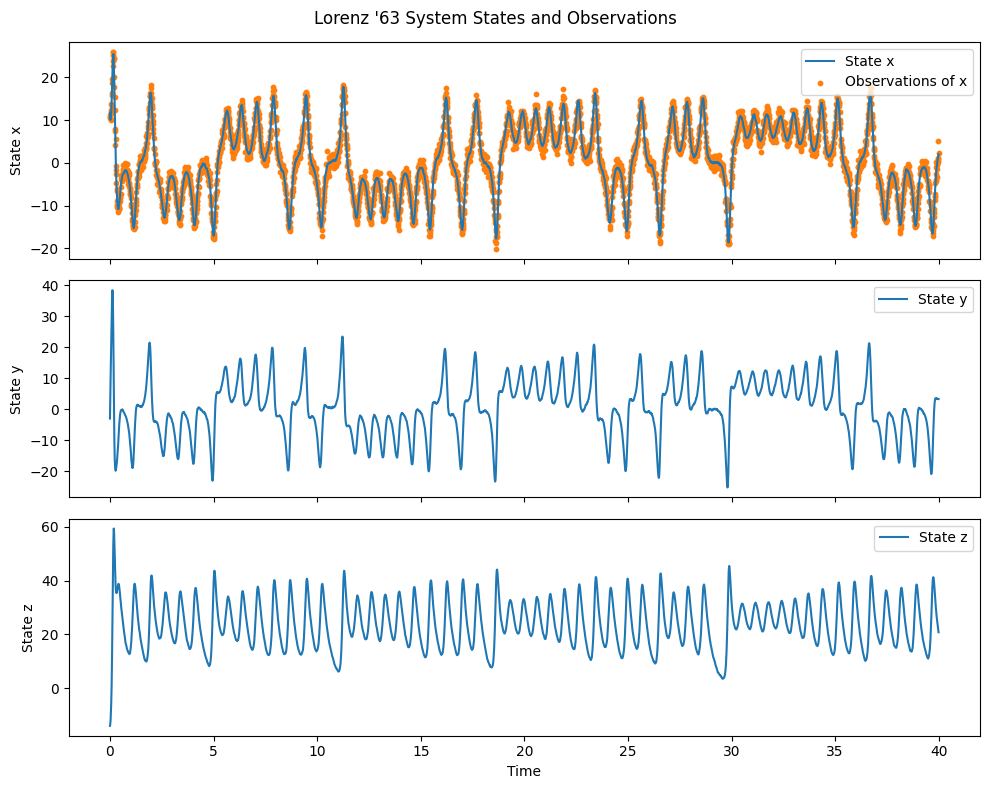

True Log Likelihood: -5978.127158268039


In [ ]:
from cd_dynamax import make_key_sequence
from cd_dynamax.src.utils.demo_utils import sample_t_emissions

keys = make_key_sequence(0)
t_emissions = sample_t_emissions(start=0.0, stop=40.0, dt=0.01, regular=True, key=next(keys))

# Simulate data using true parameters (observed at times t_emissions)
# Note that default SDE diffeqsolve settings solve using dfx.Heun() with dfx.ConstantStepSize() and dt0=0.01 step size.
states, emissions = cdnlgssm.sample(
    params=true_params,
    key=next(keys),
    num_timesteps=len(t_emissions),
    t_emissions=t_emissions,
    transition_type="path",
)

# Plot the results in a subplot with 3 rows, with observations overlaid in first emission_dims rows
fig, axs = plt.subplots(state_dim, 1, figsize=(10, 8), sharex=True)
state_labels = ['x', 'y', 'z']
for i in range(state_dim):
    axs[i].plot(t_emissions, states[:, i], label=f'State {state_labels[i]}', color='C0')
    if i < emission_dim:
        axs[i].scatter(t_emissions, emissions[:, i], label=f'Observations of {state_labels[i]}', color='C1', s=10)
    axs[i].legend()
    axs[i].set_ylabel(f'State {state_labels[i]}')
axs[-1].set_xlabel('Time')
plt.suptitle('True Lorenz \'63 System States and Observations')
plt.tight_layout()
plt.show()

# Compute likelihood of the observed data under the true parameters
filter_settings = {"filter_type": "EnKF", "state_order": "first", "N_particles": 25}
filtered = cdnlgssm.filter(
    params=true_params,
    t_emissions=t_emissions,
    emissions=emissions,
    **filter_settings
)
true_log_likelihood = filtered.marginal_loglik
print(f"True Log Likelihood: {true_log_likelihood}")

Define a numpyro model with a Neural Network based Drift Function (Uniform prior on weights)

In [17]:
nn_hidden_dims = [100] # single hidden layer with 100 units

def model(t_emissions, emissions=None):
    
    # Build NN-based drift function (uses GeLU activations)
    drift_base = make_bayesian_nn_drift(
        state_dim=state_dim,
        hidden_dims=nn_hidden_dims,   # single hidden layer with 100 units
        prior="uniform",
        prior_scale=10.0,
    ) # note that this drift takes **kwargs to allow passing known drift-params during predictive calls.
    drift = lambda x: adjust_rhs(x, drift_base(x)) # adjust_rhs truncs the drift to avoid extreme values and has it pointing inward at large radius to prevent divergence in early epochs.

    params = cdnlgssm.build_params(drift=drift, **known_params)

    # Compute (approximate) marginal log likelihood via filtering
    filtered = cdnlgssm.filter(params=params, 
                               emissions=emissions, 
                               t_emissions=t_emissions,
                               **filter_settings,
                            )

    # Use the filtering based log likelihood for the model's inference.
    numpyro.factor("log_likelihood", filtered.marginal_loglik)


In [ ]:
# SVI
num_steps = 5000

# Define an optimizer (here it is just Adam with fixed learning rate and gradient clipping)
optimizer = make_optimizer(
    initial_learning_rate=0.005,
    # decay_factor=0.5,
    # epochs_per_step=1500,
    # num_epochs=num_steps,
    use_lr_scheduler=0,
    clip_norm=1.0,
)

# Initialize at zero
init_params_dict = make_nn_init_dict(next(keys), state_dim, nn_hidden_dims)

# Now run SVI for MAP inference!
guide = AutoDelta(model, init_loc_fn=init_to_value(values=init_params_dict))
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())
svi_result = svi.run(next(keys), num_steps=num_steps, t_emissions=t_emissions, emissions=emissions)


100%|██████████| 5000/5000 [1:13:50<00:00,  1.13it/s, init loss: 30996.5106, avg. loss [4751-5000]: 8040.6035]


Log Prior under uniform prior: -2105.9997883084557


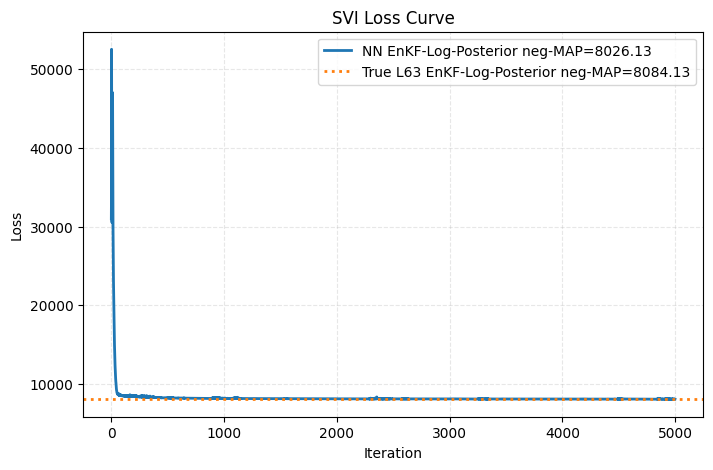

In [ ]:
# Plot training curve
# Compute log-prior of uniform prior in 3 => 100 => 3 NN parameter space of [-10, 10]
n_params = (state_dim * nn_hidden_dims[0] + nn_hidden_dims[0]) + (nn_hidden_dims[0] * state_dim + state_dim)
log_prior_uniform = -n_params * jnp.log(20.0)  # since each param has uniform prior over [-10, 10]
print(f"Log Prior under uniform prior: {log_prior_uniform}")
baseline_value = true_log_likelihood + log_prior_uniform
fig = plot_loss_curve(svi_result.losses, loss_label=f"NN EnKF-Log-Posterior neg-MAP={svi_result.losses[-1]:.2f}",
                      baseline_value=-baseline_value, baseline_label=f"True L63 EnKF-Log-Posterior neg-MAP={-baseline_value:.2f}")
plt.show()

Now, let's extract the MAP-estimated NN drift parameters, and use it for evaluations (short-term forecasting and long-term statistical behavior)

In [20]:
# Build NN-based drift function (uses GeLU activations)
map_drift_base = make_bayesian_nn_drift(
    state_dim=state_dim,
    hidden_dims=nn_hidden_dims,   # single hidden layer with 100 units
    prior="uniform",
    prior_scale=10.0,
    **guide.median(svi_result.params) # pass in learned params
) # note that this drift takes **kwargs to allow passing known drift-params during predictive calls.
map_drift = lambda x: adjust_rhs(x, map_drift_base(x)) # adjust_rhs truncs the drift to avoid extreme values and has it pointing inward at large radius to prevent divergence in early epochs.

map_params = cdnlgssm.build_params(drift=map_drift, **known_params)


Below, we will generate a new test trajectory from the true model, then do filtering and forecasting (using both true and learned models) to evaluate short-term forecasting performance. Note that the diffusion in the true SDE model (combined with the chaotic sensitivies of the Lorenz drift) makes even high-quality forecasts diverge quickly.

In [122]:
# Now, generate a new testing trajectory from the true model. 
# Do filtering then forecasting (using true and learned models) 
# to evaluate short-term forecasting performance
test_t_emissions = sample_t_emissions(start=0.0, stop=1000.0, dt=0.01, regular=True, key=next(keys))

test_states, test_emissions = cdnlgssm.sample(
    params=true_params,
    key=next(keys),
    num_timesteps=len(test_t_emissions),
    t_emissions=test_t_emissions,
    transition_type="path",
)

from cd_dynamax import cdnlgssm_forecast, EnKFHyperParams
from tensorflow_probability.substrates.jax.distributions import MultivariateNormalFullCovariance as MVN
# Perform filtering on test data using true parameters
# feel free to change T0, T_filter_end, T_forecast_end to test different filtering/forecasting windows within the test data
# note that the diffusion here makes tractable forecast horizons much shorter than in deterministic L63 systems
def filter_then_forecast(params, key=0, T0 = 80.0, T_filter_end=83.0, T_forecast_end=90.0):
    # Create a sequence of keys
    keys = make_key_sequence(key)

    # Figure out the time points for filtering
    start_idx_filter = jnp.where(test_t_emissions >= T0)[0][0]
    stop_idx_filter = jnp.where(test_t_emissions >= T_filter_end)[0][0]

    # Figure out the time points for forecasting
    start_idx_forecast = jnp.where(test_t_emissions >= T_filter_end)[0][0]
    stop_idx_forecast = jnp.where(test_t_emissions >= T_forecast_end)[0][0]
    
    assert start_idx_filter < stop_idx_filter, "Filtering time points are invalid."
    assert start_idx_forecast < stop_idx_forecast, "Forecasting time points are invalid."

    # Run filter on filtering time points
    filtered = cdnlgssm.filter(
        params=params,
        emissions=test_emissions[start_idx_filter:stop_idx_filter],
        t_emissions=test_t_emissions[start_idx_filter:stop_idx_filter],
        **filter_settings,
    )
    
    # Initialize forecast with last filtered state
    init_time = test_t_emissions[stop_idx_filter-1]
    init_forecast = MVN(filtered.filtered_means[-1, :], filtered.filtered_covariances[-1, :])

    # Run forecast on forecasting time points
    forecasted = cdnlgssm_forecast(
        params=params,
        init_forecast=init_forecast,
        t_init=init_time,
        t_forecast=test_t_emissions[start_idx_forecast:stop_idx_forecast],
        filter_hyperparams=EnKFHyperParams(**{key: filter_settings[key] for key in filter_settings if key not in ['filter_type']}),
    )
    
    return filtered, forecasted, start_idx_filter, stop_idx_filter, start_idx_forecast, stop_idx_forecast

def plot_filter_then_forecast(filtered, forecasted, start_idx_filter, stop_idx_filter, start_idx_forecast, stop_idx_forecast, t_emissions=test_t_emissions, emissions=test_emissions, states=test_states, title_suffix=""):
    fig, axs = plt.subplots(state_dim, 1, figsize=(10, 6), sharex=True)
    for i in range(state_dim):
        # Plot true states
        axs[i].plot(t_emissions[start_idx_filter:stop_idx_forecast], states[start_idx_filter:stop_idx_forecast, i], label=f'True state dim {i}', color='C3')

        # Plot filtered means
        filter_times = t_emissions[start_idx_filter:stop_idx_filter]
        axs[i].plot(filter_times, filtered.filtered_means[:, i], label=f'Filtered mean dim {i}', color='C0')

        # Plot forecasted means
        forecast_times = t_emissions[start_idx_forecast:stop_idx_forecast]
        axs[i].plot(forecast_times, forecasted.forecasted_state_means[:, i], label=f'Forecasted mean dim {i}', color='C2')
        
        # Plot forecasted uncertainty as shaded region
        forecasted_std = jnp.sqrt(jnp.diagonal(forecasted.forecasted_state_covariances, axis1=1, axis2=2)[:, i])
        axs[i].fill_between(forecast_times.squeeze(),
                            forecasted.forecasted_state_means[:, i] - 2 * forecasted_std,
                            forecasted.forecasted_state_means[:, i] + 2 * forecasted_std,
                            color='C2', alpha=0.3, label='Forecast ±2 stddev')

        # Note where filtering ends and forecasting begins
        axs[i].axvline(x=t_emissions[stop_idx_filter-1], color='k', linestyle='--', label='Forecast start')

        if i < emission_dim:
            # Plot emissions
            axs[i].scatter(t_emissions[start_idx_filter:stop_idx_forecast], emissions[start_idx_filter:stop_idx_forecast, i], label=f'Observations of dim {i}', color='C1', s=10)

        axs[i].legend(loc='upper right')
        axs[i].set_ylabel(f'State dim {i}')
    axs[-1].set_xlabel('Time')
    plt.suptitle(f'Filtering and Forecasting Results {title_suffix}')
    plt.tight_layout()
    plt.show()

[make_t_emissions] Generated 100000 points from 0.0 to 1000.0 with avg step ~0.0100
[make_t_emissions] Smallest time step = 0.010000
Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path


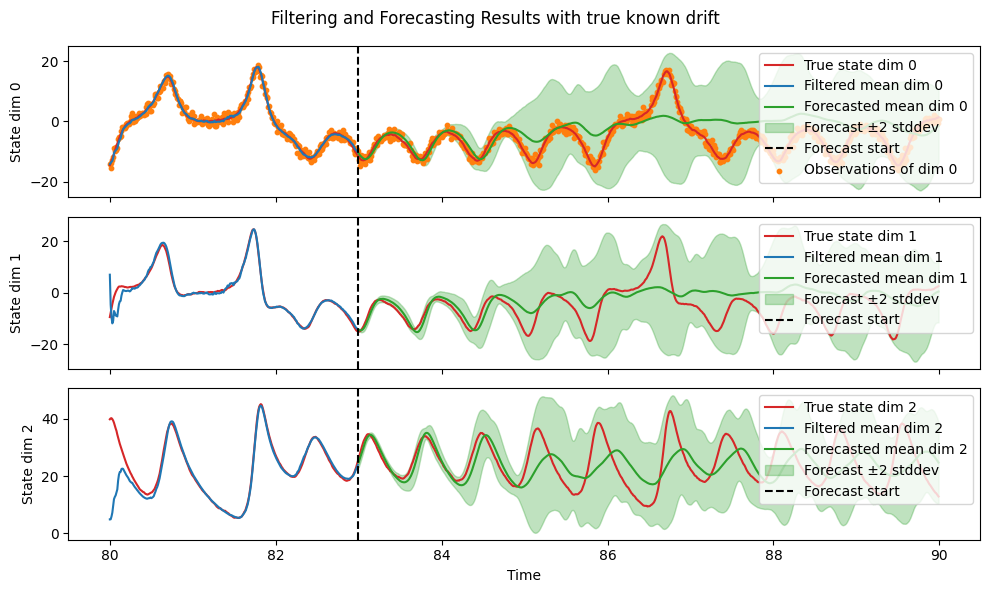

In [123]:
# Filter then forecast using true model
plot_filter_then_forecast(*filter_then_forecast(params=true_params), title_suffix="with true known drift")

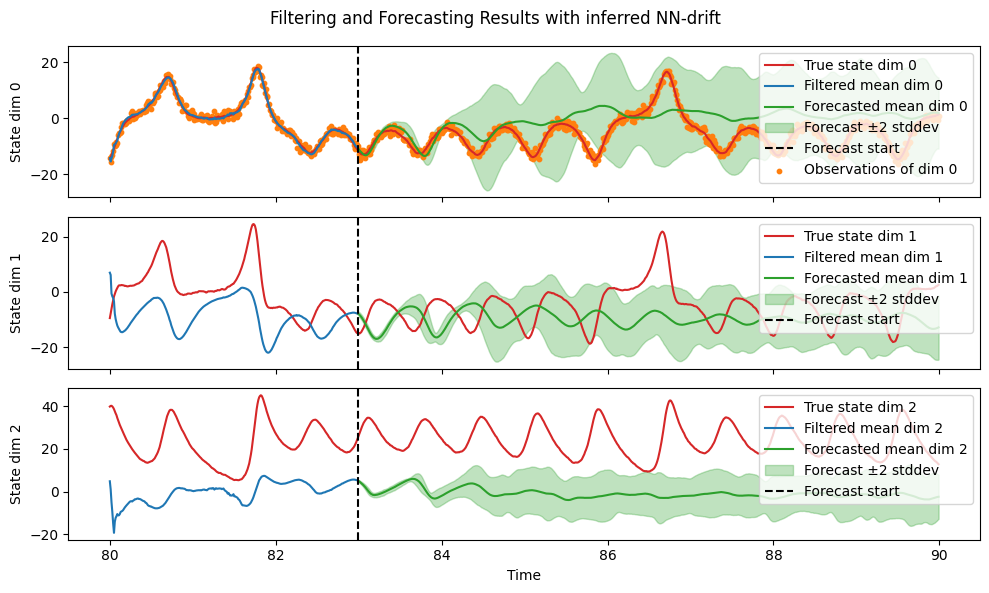

In [124]:
# Filter then forecast using learned Neural SDE map parameters
plot_filter_then_forecast(*filter_then_forecast(params=map_params), title_suffix="with inferred NN-drift")

Next, we will look at the long-term statistical behavior of the learned vs true models by simulating a long trajectory from each and plotting histograms. Feel free to compute other things, like Lyapunov exponents, etc.!

Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path
Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path


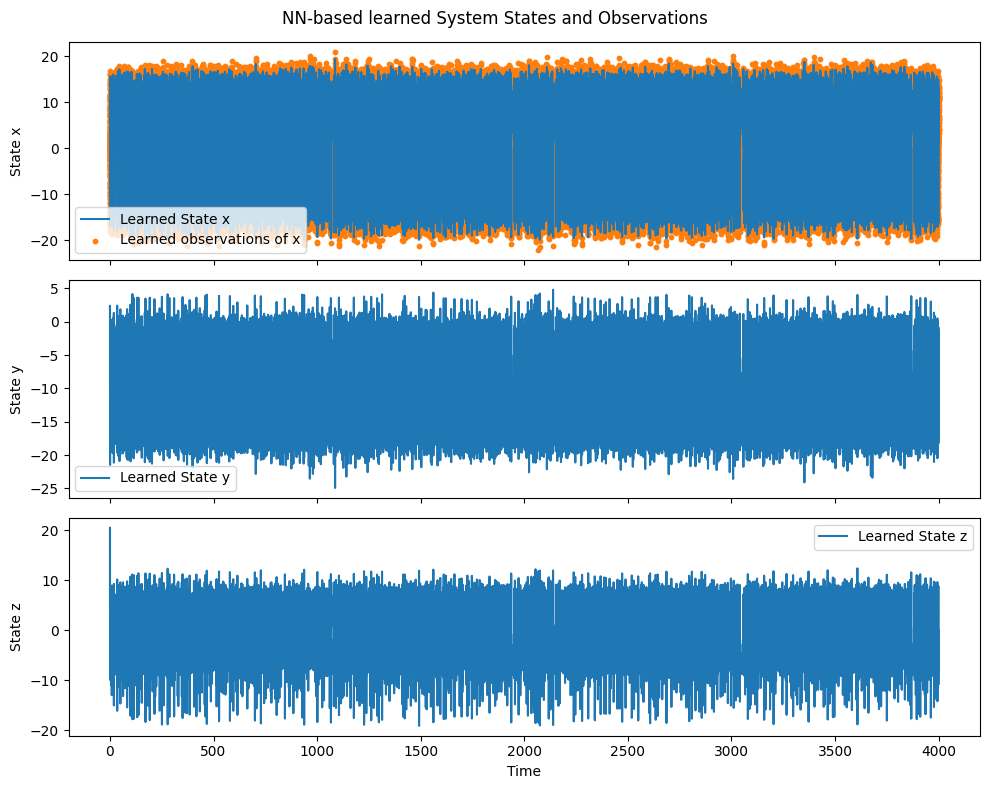

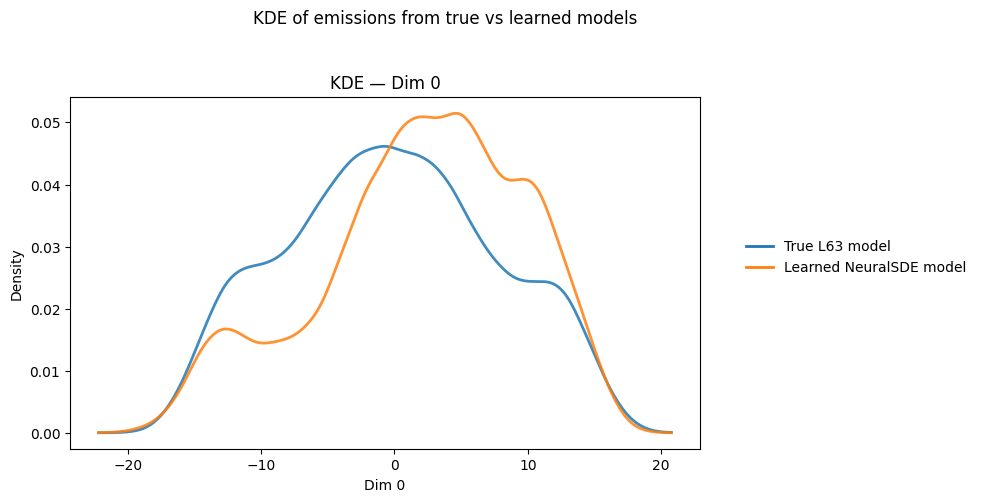

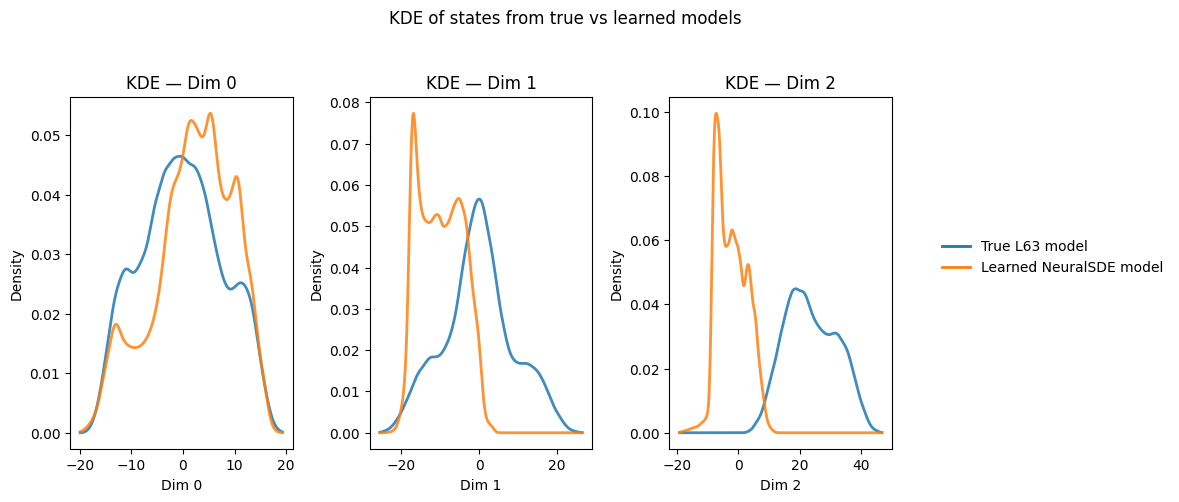

In [121]:
long_t_emissions = jnp.arange(start=0.0, stop=4000, step=0.01).reshape(-1, 1)

# Long simulation with learned parameters
states_learned, emissions_learned = cdnlgssm.sample(
    params=map_params,
    key=next(keys),
    num_timesteps=len(long_t_emissions),
    t_emissions=long_t_emissions,
    transition_type="path",
)

# Long simulation with true parameters for comparison (training data is too short to see true attractor)
states_true_long, emissions_true_long = cdnlgssm.sample(
    params=true_params,
    key=next(keys),
    num_timesteps=len(long_t_emissions),
    t_emissions=long_t_emissions,
    transition_type="path",
)

# Plot the results in a subplot with 3 rows, with observations overlaid in first emission_dims rows
fig, axs = plt.subplots(state_dim, 1, figsize=(10, 8), sharex=True)
state_labels = ['x', 'y', 'z']
for i in range(state_dim):
    axs[i].plot(long_t_emissions, states_learned[:, i], label=f'Learned State {state_labels[i]}', color='C0')
    if i < emission_dim:
        axs[i].scatter(long_t_emissions, emissions_learned[:, i], label=f'Learned observations of {state_labels[i]}', color='C1', s=10)
    axs[i].legend()
    axs[i].set_ylabel(f'State {state_labels[i]}')
axs[-1].set_xlabel('Time')
plt.suptitle('NN-based learned System States and Observations')
plt.tight_layout()
plt.show()

# Plot KDE of trajectories
burnin_frac = 0.5
burnin_idx = int(burnin_frac * long_t_emissions.shape[0])
fig = plot_traj_kde({"True L63 model": emissions_true_long[burnin_idx:], "Learned NeuralSDE model": emissions_learned[burnin_idx:]},
                    title="KDE of emissions from true vs learned models")
plt.show()

fig = plot_traj_kde({"True L63 model": states_true_long[burnin_idx:], "Learned NeuralSDE model": states_learned[burnin_idx:]},
                    title="KDE of states from true vs learned models")
plt.show()

